In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_880\266577964.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


<Axes: >

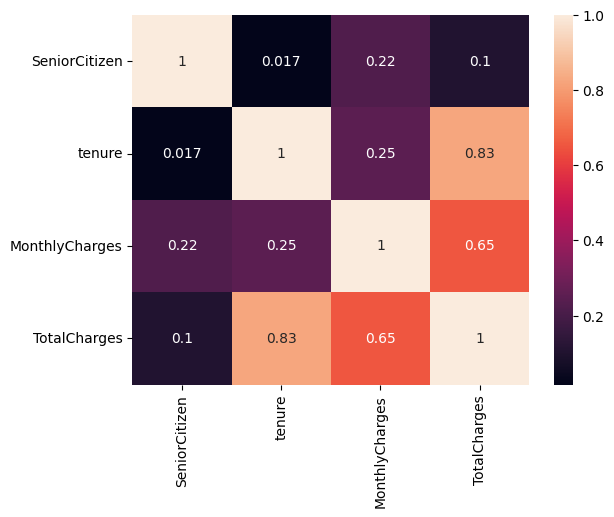

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

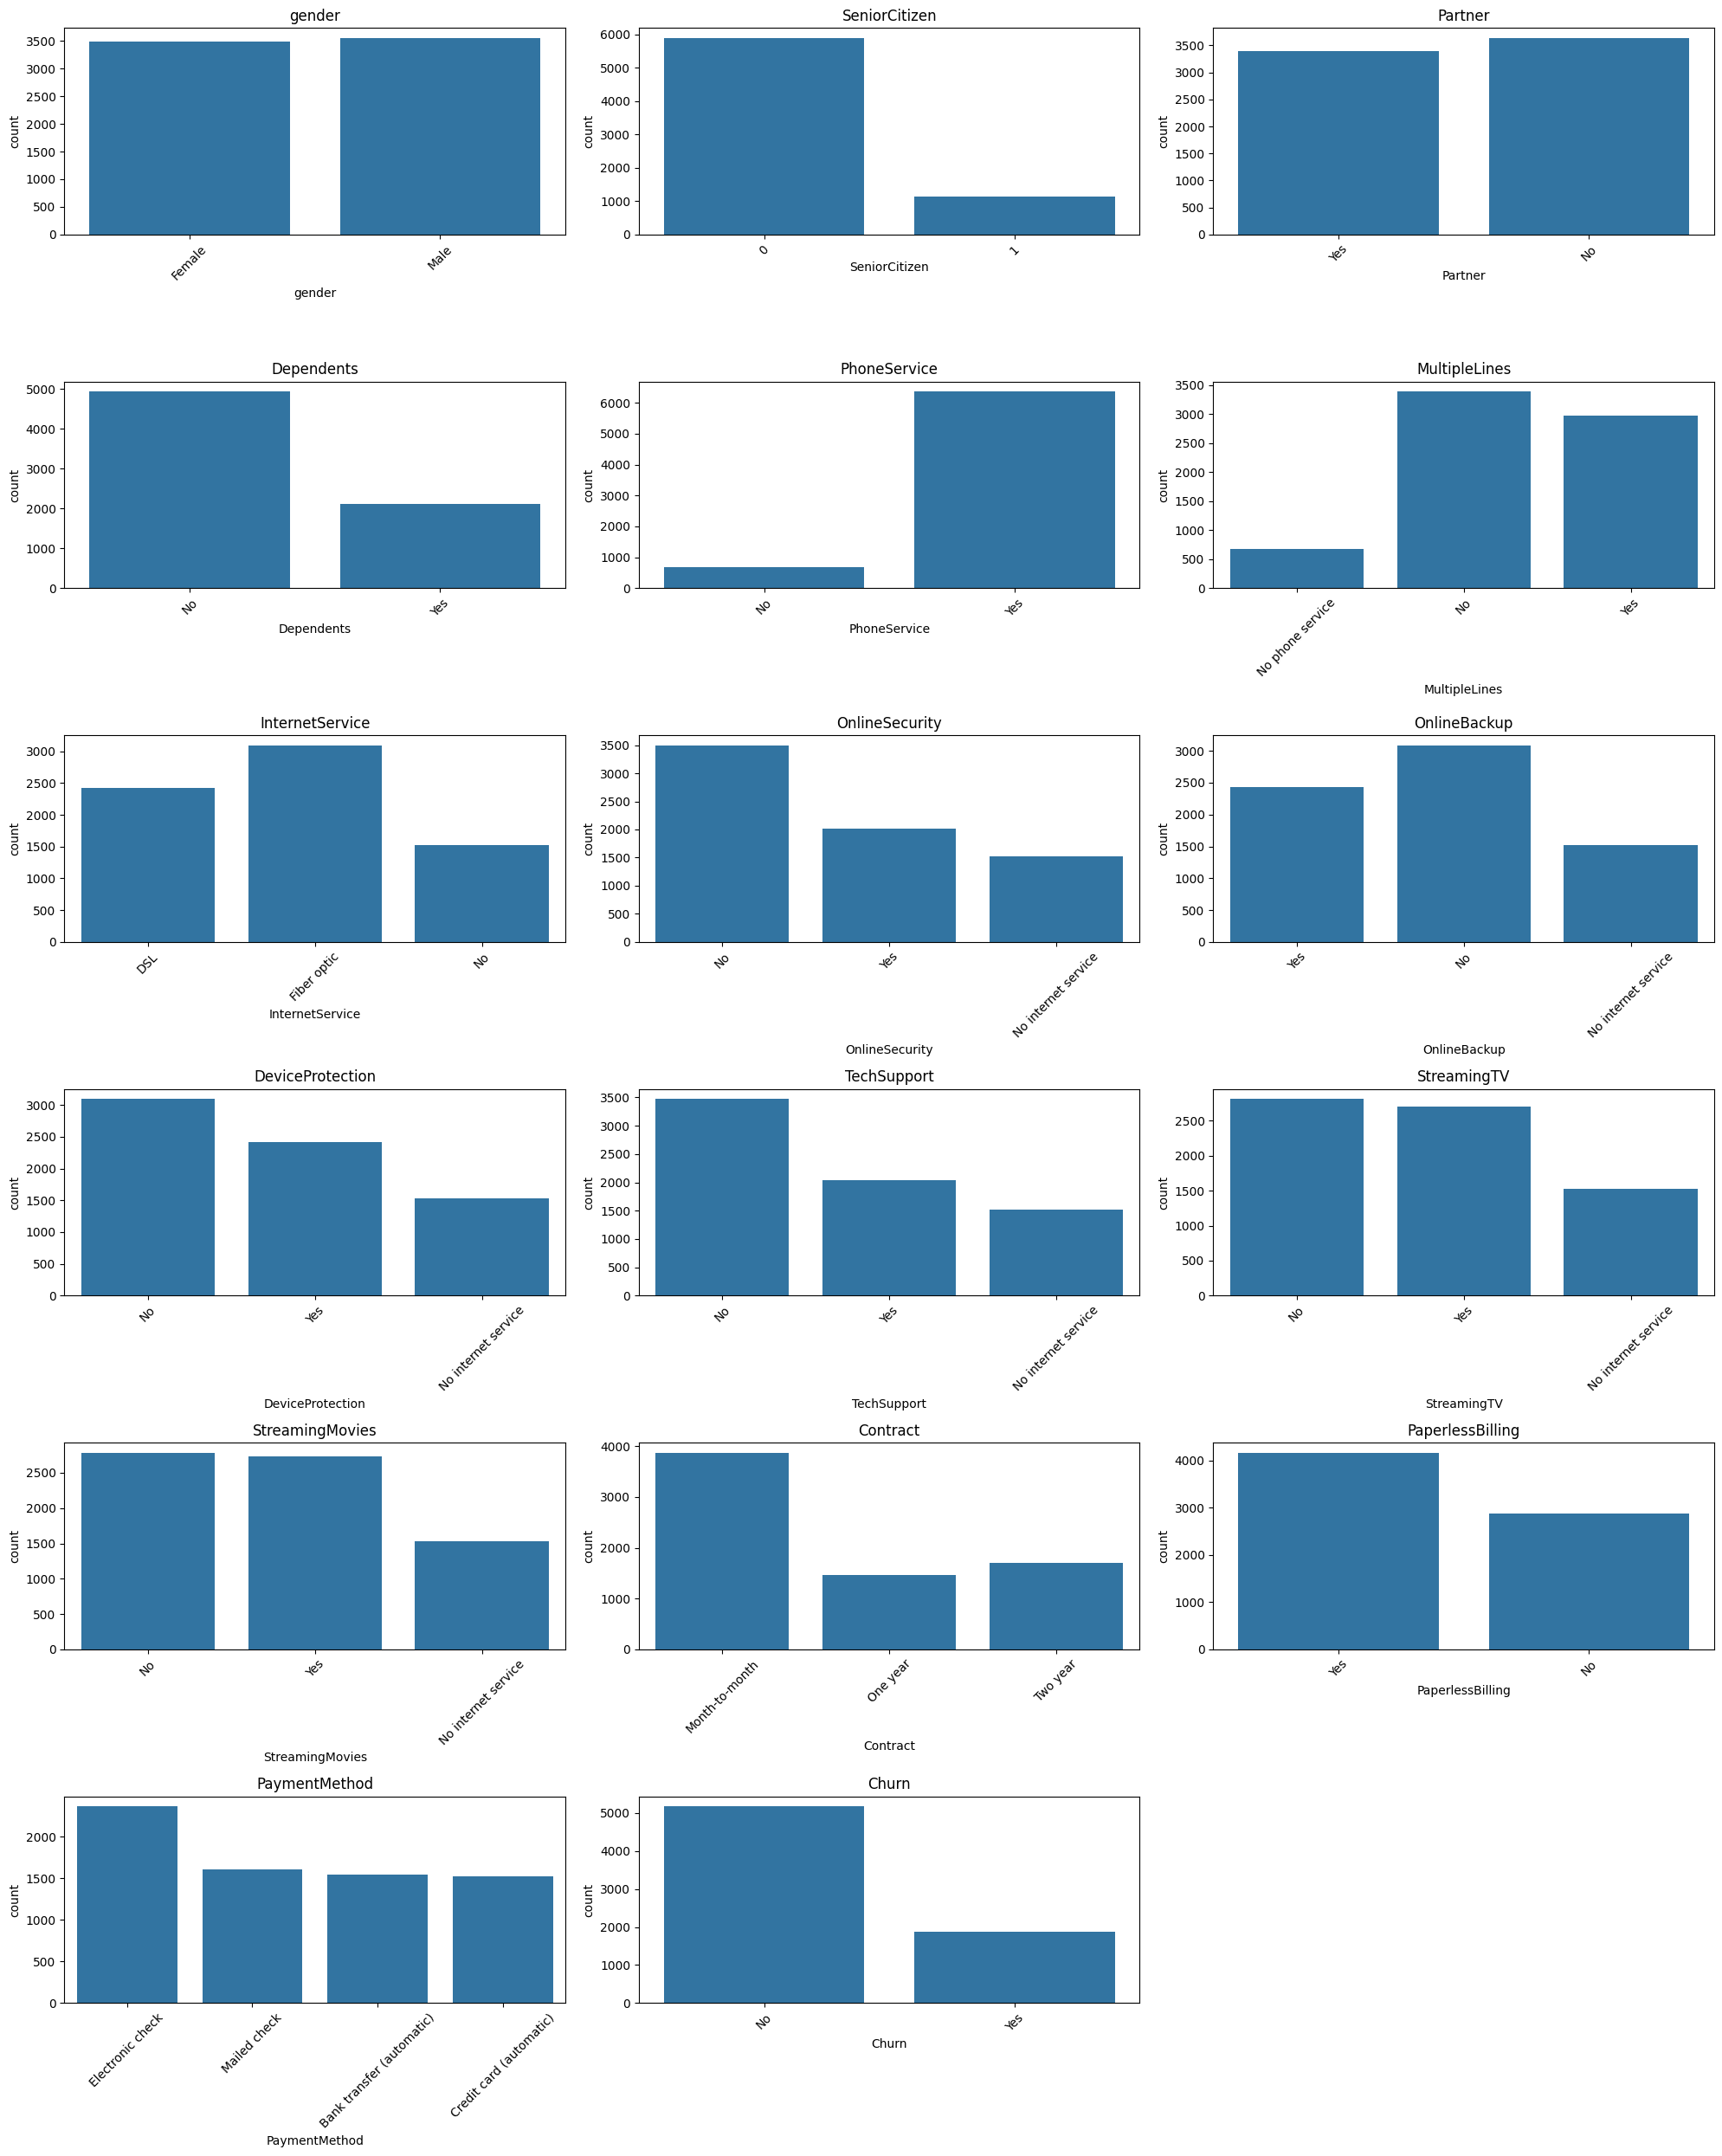

In [11]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]
plt.figure(figsize=(20, 25))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(6, 3, i)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

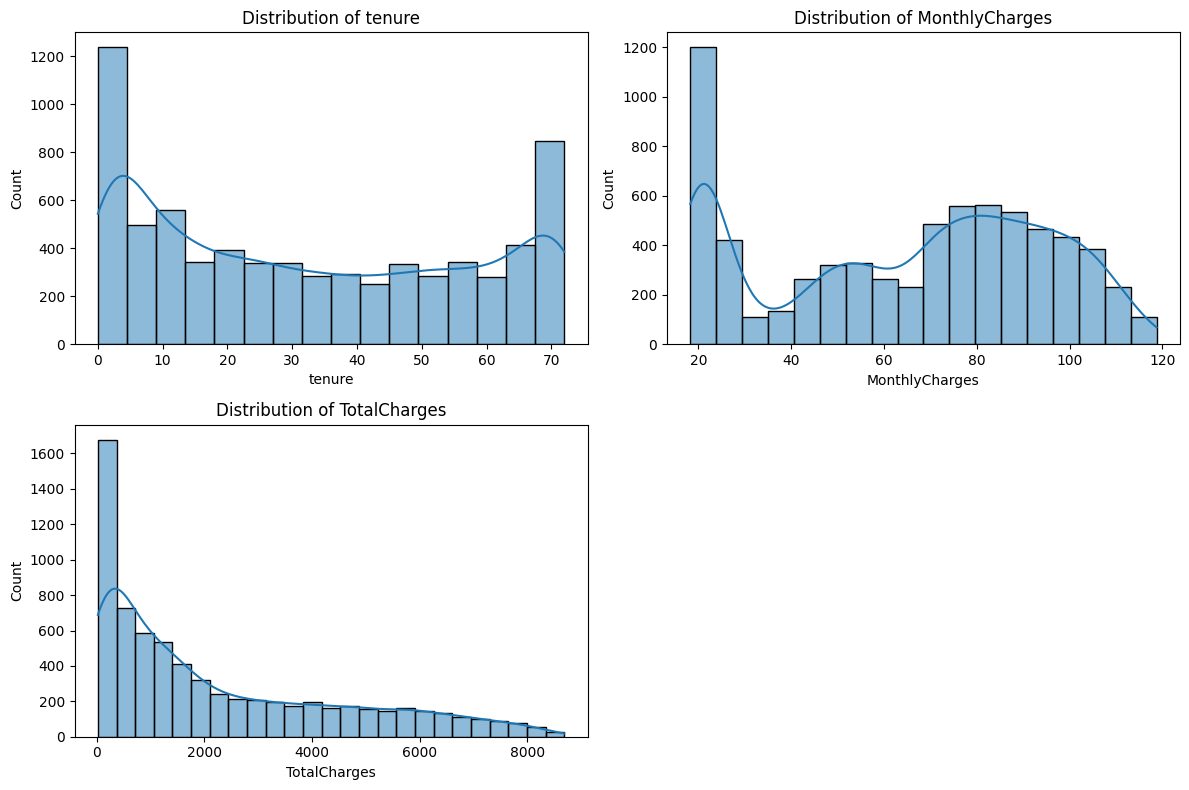

In [12]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
df['TotalCharges'] = np.log1p(df['TotalCharges'])

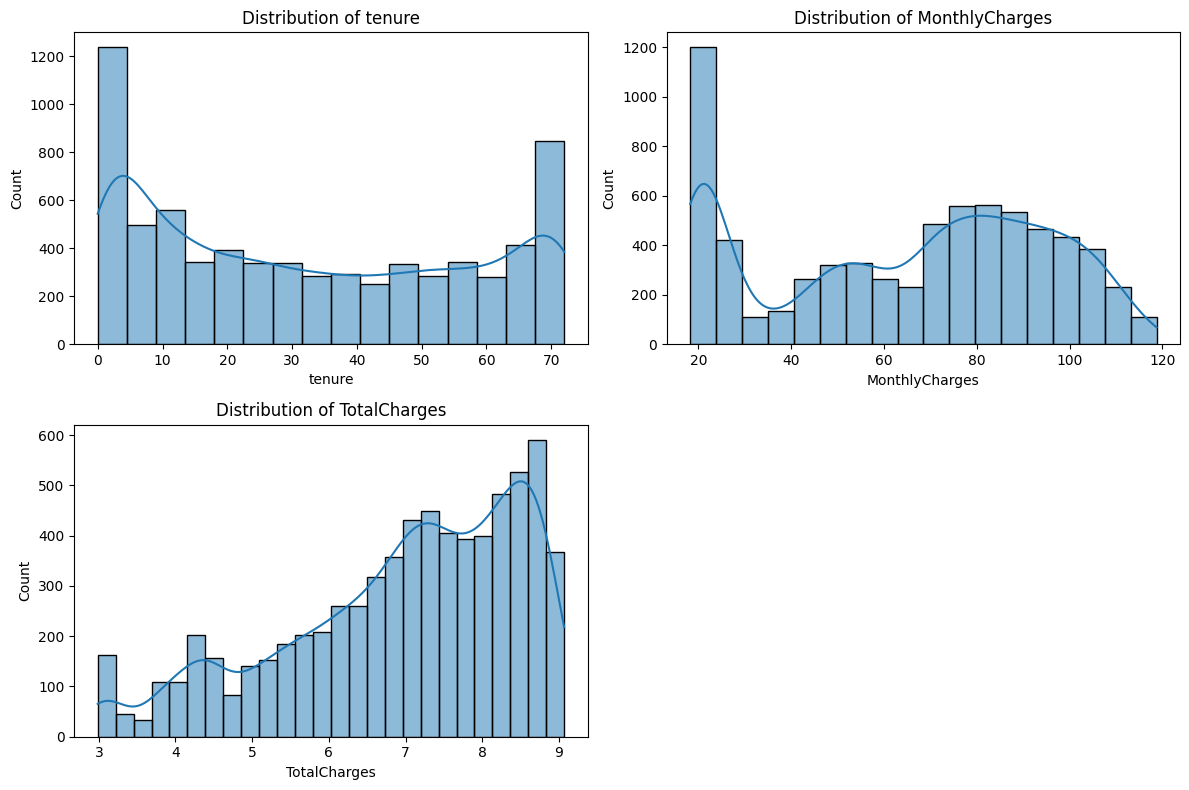

In [14]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [15]:
x=df.drop(columns=['Churn','customerID'])
y=df['Churn'].map({'Yes': 1, 'No': 0})

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# 🔵 Binary columns (Yes/No)
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

# 🟡 One-hot encoding columns
categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

# 🟢 Numerical columns (to be scaled)
scaled_numeric_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# ⚪ Numeric but NOT scaled
pass_through_cols = [
    'SeniorCitizen'
]
preprocessor = ColumnTransformer(
    transformers=[
        
        # 🔵 binary encoding
        ('binary', OrdinalEncoder(), binary_cols),

        # 🟡 one-hot encoding
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols),

        # 🟢 scaled numerical features
        ('scaled_num', StandardScaler(), scaled_numeric_cols),

        # ⚪ passthrough (no scaling)
        ('pass', 'passthrough', pass_through_cols)
    ]
)

In [17]:
x = preprocessor.fit_transform(x)
print(f"After preprocessing — Shape: {x.shape}")


After preprocessing — Shape: (7043, 40)


In [18]:
feature_names = preprocessor.get_feature_names_out()

In [19]:
x = pd.DataFrame(x, columns=feature_names)

In [20]:
x.columns

Index(['binary__gender', 'binary__Partner', 'binary__Dependents',
       'binary__PhoneService', 'binary__PaperlessBilling',
       'categorical__MultipleLines_No',
       'categorical__MultipleLines_No phone service',
       'categorical__MultipleLines_Yes', 'categorical__InternetService_DSL',
       'categorical__InternetService_Fiber optic',
       'categorical__InternetService_No', 'categorical__OnlineSecurity_No',
       'categorical__OnlineSecurity_No internet service',
       'categorical__OnlineSecurity_Yes', 'categorical__OnlineBackup_No',
       'categorical__OnlineBackup_No internet service',
       'categorical__OnlineBackup_Yes', 'categorical__DeviceProtection_No',
       'categorical__DeviceProtection_No internet service',
       'categorical__DeviceProtection_Yes', 'categorical__TechSupport_No',
       'categorical__TechSupport_No internet service',
       'categorical__TechSupport_Yes', 'categorical__StreamingTV_No',
       'categorical__StreamingTV_No internet service'

In [21]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   binary__gender                                        7043 non-null   float64
 1   binary__Partner                                       7043 non-null   float64
 2   binary__Dependents                                    7043 non-null   float64
 3   binary__PhoneService                                  7043 non-null   float64
 4   binary__PaperlessBilling                              7043 non-null   float64
 5   categorical__MultipleLines_No                         7043 non-null   float64
 6   categorical__MultipleLines_No phone service           7043 non-null   float64
 7   categorical__MultipleLines_Yes                        7043 non-null   float64
 8   categorical__InternetService_DSL                      7043 non-null  

In [22]:
x['scaled_num__TotalCharges']=x['scaled_num__TotalCharges'].fillna(x['scaled_num__TotalCharges'].median(), inplace=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_880\1393560861.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x['scaled_num__TotalCharges']=x['scaled_num__TotalCharges'].fillna(x['scaled_num__TotalCharges'].median(), inplace=True)


In [23]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   binary__gender                                        7043 non-null   float64
 1   binary__Partner                                       7043 non-null   float64
 2   binary__Dependents                                    7043 non-null   float64
 3   binary__PhoneService                                  7043 non-null   float64
 4   binary__PaperlessBilling                              7043 non-null   float64
 5   categorical__MultipleLines_No                         7043 non-null   float64
 6   categorical__MultipleLines_No phone service           7043 non-null   float64
 7   categorical__MultipleLines_Yes                        7043 non-null   float64
 8   categorical__InternetService_DSL                      7043 non-null  

In [24]:
x.isnull().sum().sum()

np.int64(0)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,          # your preprocessed features (after ColumnTransformer)
    y,          # target (Churn)
    test_size=0.2,
    random_state=42,
    stratify=y  # 🔥 IMPORTANT for imbalanced data
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 40)
Test shape: (1409, 40)


In [26]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)

y_pred_lr = log_model.predict(X_test)
y_prob_lr = log_model.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.849125526363378


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8207109457748843


In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# imbalance ratio
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

ModuleNotFoundError: No module named 'xgboost'